# Final Risk and Robustness

## Crypto Alpha Across Horizons

The untouched final holdout has already been opened and the three pre-frozen continuation implementations have already passed the project's primary survival rule.

This notebook is **post-validation characterization only**. It does not search for a better strategy.

It asks five downstream questions:

1. How much execution-cost headroom remains in the unseen sample?
2. What do realized drawdowns and tail losses look like?
3. How broad is performance through time?
4. Does a dollar-neutral portfolio still carry realized crypto-market exposure?
5. Is the result broad across positions/assets, or concentrated in a few names?

### Hard boundary

Nothing in this notebook may change:

- finalist identity;
- mapping, formation, holding, or cadence;
- point-in-time universe logic;
- the primary 20-bps cost assumption;
- the Step-12 survival rule;
- the 3/3 final-holdout conclusion.

### Public-package execution design

The canonical post-validation engine reconstructed the exact frozen holdings from the native 1h holdout data and matched the Step-12 gross return paths with zero difference before computing implementation diagnostics.

The public notebook keeps the recruiter-facing layer lighter:

- cost, risk, and time diagnostics are recomputed directly from the exact Step-12 return/IC paths;
- market betas are recomputed from the frozen common-48h exposure panel;
- concentration statistics are recomputed from the exact saved asset-contribution detail;
- position-breadth and long/short exposure summaries are checked against the canonical frozen outputs.

No new signal or portfolio is created here.

In [1]:
from pathlib import Path
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display


def locate_project_root():
    env_root = os.getenv("CRYPTO_ALPHA_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / "data").is_dir():
            return candidate

    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd / "crypto-alpha-research",
        cwd.parent / "crypto-alpha-research",
    ]
    for candidate in candidates:
        if (candidate / "data").is_dir() and (
            (candidate / "notebooks").is_dir()
            or (candidate / "public_notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. Set CRYPTO_ALPHA_ROOT "
        "to the crypto-alpha-research folder."
    )


PROJECT_ROOT = locate_project_root()
RESEARCH_DIR = PROJECT_ROOT / "data" / "research"
STEP13_DIR = RESEARCH_DIR / "step13"

FINALISTS = ["ECON", "BAL", "SHARP"]
CADENCE_HOURS = {"ECON": 24, "BAL": 48, "SHARP": 8}
PRIMARY_COST_BPS = 20.0
COST_GRID_BPS = [0.0, 7.0, 20.0, 40.0]

print("Project root:", PROJECT_ROOT)
print("Step-13 frozen output directory:", STEP13_DIR)

Project root: /Users/owensimon/crypto-alpha-research
Step-13 frozen output directory: /Users/owensimon/crypto-alpha-research/data/research/step13


## 1. Frozen-input integrity

All diagnostics must remain downstream of the exact Step-12 holdout paths.

The first gate therefore rechecks the 20-bps identity and exact break-even costs from the native-cadence return/turnover series.

In [2]:
returns_path = RESEARCH_DIR / "step12_finalist_return_series.parquet"
metrics_path = RESEARCH_DIR / "step12_final_holdout_metrics.csv"
ic_path = RESEARCH_DIR / "step12_finalist_ic_series.parquet"
common48_gross_path = RESEARCH_DIR / "step12_finalist_common_48h_gross_returns.parquet"
degradation_path = RESEARCH_DIR / "step12_final_holdout_degradation.csv"

for path in [
    returns_path, metrics_path, ic_path,
    common48_gross_path, degradation_path,
]:
    if not path.exists():
        raise FileNotFoundError(path)

returns_long = pd.read_parquet(returns_path).copy()
holdout_metrics = pd.read_csv(metrics_path).copy()
ic_long = pd.read_parquet(ic_path).copy()
common48_gross = pd.read_parquet(common48_gross_path).copy()
degradation = pd.read_csv(degradation_path).copy()

returns_long["timestamp"] = pd.to_datetime(returns_long["timestamp"], utc=True)
ic_long["timestamp"] = pd.to_datetime(ic_long["timestamp"], utc=True)
common48_gross.index = pd.to_datetime(common48_gross.index, utc=True)

assert set(returns_long["finalist"]) == set(FINALISTS)
assert set(holdout_metrics["finalist"]) == set(FINALISTS)
assert set(ic_long["finalist"]) == set(FINALISTS)
assert list(common48_gross.columns) == FINALISTS

integrity_rows = []
for finalist in FINALISTS:
    x = (
        returns_long.loc[returns_long["finalist"].eq(finalist)]
        .sort_values("timestamp")
        .set_index("timestamp")
    )
    saved = holdout_metrics.loc[
        holdout_metrics["finalist"].eq(finalist)
    ].iloc[0]

    reconstructed_net20 = (
        x["gross_return"] - PRIMARY_COST_BPS * 1e-4 * x["turnover"]
    )
    max_net20_diff = float(
        (reconstructed_net20 - x["net20_return"]).abs().max()
    )
    exact_be = float(
        x["gross_return"].sum() / x["turnover"].sum() * 1e4
    )

    assert max_net20_diff < 1e-12
    assert np.isclose(
        exact_be,
        float(saved["break_even_cost_bps"]),
        rtol=1e-10,
        atol=1e-10,
    )

    integrity_rows.append(
        {
            "finalist": finalist,
            "max_net20_identity_diff": max_net20_diff,
            "path_break_even_bps": exact_be,
            "saved_break_even_bps": float(saved["break_even_cost_bps"]),
        }
    )

integrity = pd.DataFrame(integrity_rows)
display(integrity)
print("FROZEN INPUT INTEGRITY: PASS")

,finalist,max_net20_identity_diff,path_break_even_bps,saved_break_even_bps
0,ECON,8.673617e-19,28.495171,28.495171
1,BAL,3.469447e-18,42.007634,42.007634
2,SHARP,1.734723e-18,31.723803,31.723803


FROZEN INPUT INTEGRITY: PASS


## 2. Execution-cost sensitivity

The primary assumption remains **20 bps per unit of full-L1 turnover**.

The 0 / 7 / 20 / 40-bps grid is descriptive sensitivity only. Exact break-even cost is the realized execution cost at which arithmetic mean return becomes zero.

In [3]:
def annualized_mean_return(r, periods_per_year):
    x = pd.Series(r).dropna().astype(float)
    return float(x.mean() * periods_per_year)


def annualized_volatility(r, periods_per_year):
    x = pd.Series(r).dropna().astype(float)
    if len(x) < 2:
        return np.nan
    return float(x.std(ddof=1) * np.sqrt(periods_per_year))


def annualized_sharpe(r, periods_per_year):
    x = pd.Series(r).dropna().astype(float)
    if len(x) < 2:
        return np.nan
    sd = float(x.std(ddof=1))
    if not np.isfinite(sd) or sd <= 0:
        return np.nan
    return float(x.mean() / sd * np.sqrt(periods_per_year))


def max_drawdown_from_returns(r):
    x = pd.Series(r).dropna().astype(float)
    wealth = (1.0 + x).cumprod()
    return float((wealth / wealth.cummax() - 1.0).min())


rows = []
for finalist in FINALISTS:
    x = (
        returns_long.loc[
            returns_long["finalist"].eq(finalist),
            ["timestamp", "gross_return", "turnover"],
        ]
        .sort_values("timestamp")
        .set_index("timestamp")
    )

    ppy = 365.25 * 24.0 / CADENCE_HOURS[finalist]
    exact_be = float(
        x["gross_return"].sum() / x["turnover"].sum() * 1e4
    )
    ann_turnover = float(x["turnover"].mean() * ppy)

    scenario_costs = list(
        dict.fromkeys(COST_GRID_BPS + [exact_be])
    )

    for cost_bps in scenario_costs:
        net = (
            x["gross_return"]
            - float(cost_bps) * 1e-4 * x["turnover"]
        )
        wealth = (1.0 + net).cumprod()

        rows.append(
            {
                "finalist": finalist,
                "cost_bps": float(cost_bps),
                "is_exact_break_even": bool(
                    np.isclose(cost_bps, exact_be, atol=1e-9)
                ),
                "annualized_mean_return": annualized_mean_return(net, ppy),
                "annualized_volatility": annualized_volatility(net, ppy),
                "annualized_sharpe": annualized_sharpe(net, ppy),
                "cumulative_return": float(wealth.iloc[-1] - 1.0),
                "max_drawdown": max_drawdown_from_returns(net),
                "annualized_turnover": ann_turnover,
                "exact_break_even_cost_bps": exact_be,
            }
        )

cost_sensitivity = pd.DataFrame(rows)

frozen_cost_path = STEP13_DIR / "13A_cost_sensitivity_metrics.csv"
if not frozen_cost_path.exists():
    raise FileNotFoundError(frozen_cost_path)

frozen_cost = pd.read_csv(frozen_cost_path)

compare_cols = [
    "annualized_mean_return",
    "annualized_volatility",
    "annualized_sharpe",
    "cumulative_return",
    "max_drawdown",
    "annualized_turnover",
    "exact_break_even_cost_bps",
]

merged = cost_sensitivity.merge(
    frozen_cost[
        ["finalist", "cost_bps", "is_exact_break_even"] + compare_cols
    ],
    on=["finalist", "cost_bps", "is_exact_break_even"],
    suffixes=("_new", "_frozen"),
    validate="one_to_one",
)

max_cost_diff = 0.0
for col in compare_cols:
    diff = (
        merged[f"{col}_new"] - merged[f"{col}_frozen"]
    ).abs().max()
    max_cost_diff = max(max_cost_diff, float(diff))

assert max_cost_diff < 1e-10

headline_rows = []
for finalist in FINALISTS:
    sub = cost_sensitivity.loc[
        cost_sensitivity["finalist"].eq(finalist)
    ]
    headline_rows.append(
        {
            "finalist": finalist,
            "gross_sharpe": float(
                sub.loc[np.isclose(sub["cost_bps"], 0.0), "annualized_sharpe"].iloc[0]
            ),
            "net7_sharpe": float(
                sub.loc[np.isclose(sub["cost_bps"], 7.0), "annualized_sharpe"].iloc[0]
            ),
            "net20_sharpe": float(
                sub.loc[np.isclose(sub["cost_bps"], 20.0), "annualized_sharpe"].iloc[0]
            ),
            "net40_sharpe": float(
                sub.loc[np.isclose(sub["cost_bps"], 40.0), "annualized_sharpe"].iloc[0]
            ),
            "break_even_bps": float(
                sub["exact_break_even_cost_bps"].iloc[0]
            ),
            "headroom_over_20_bps": float(
                sub["exact_break_even_cost_bps"].iloc[0] - 20.0
            ),
            "annualized_turnover": float(
                sub["annualized_turnover"].iloc[0]
            ),
        }
    )

cost_headline = pd.DataFrame(headline_rows)
display(cost_headline.round(6))
print("Cost-sensitivity reproduction vs frozen Step-13A output: PASS")

,finalist,gross_sharpe,net7_sharpe,net20_sharpe,net40_sharpe,break_even_bps,headroom_over_20_bps,annualized_turnover
0,ECON,0.333832,0.251783,0.099474,-0.134632,28.495171,8.495171,26.302446
1,BAL,0.788064,0.656699,0.412757,0.037637,42.007634,22.007634,38.184114
2,SHARP,1.132380,0.882447,0.418355,-0.295171,31.723803,11.723803,72.686035


Cost-sensitivity reproduction vs frozen Step-13A output: PASS


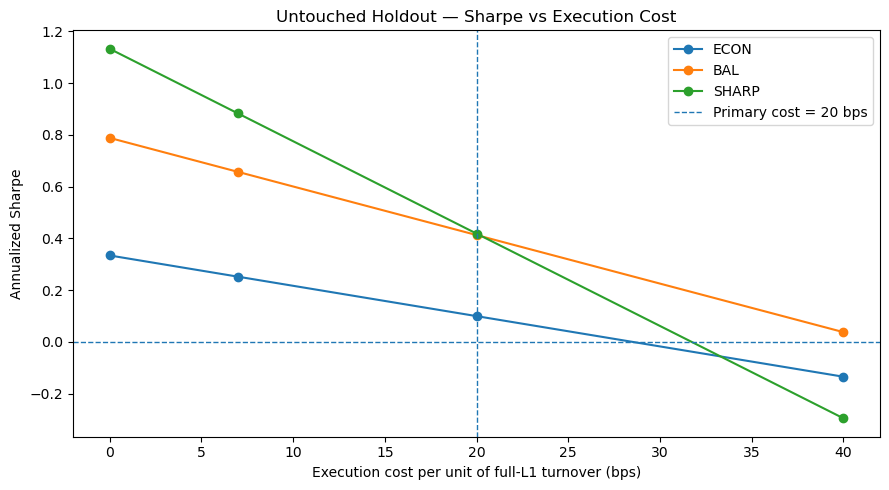

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for finalist in FINALISTS:
    sub = (
        cost_sensitivity.loc[
            cost_sensitivity["finalist"].eq(finalist)
            & cost_sensitivity["cost_bps"].isin(COST_GRID_BPS)
        ]
        .sort_values("cost_bps")
    )
    ax.plot(
        sub["cost_bps"],
        sub["annualized_sharpe"],
        marker="o",
        label=finalist,
    )

ax.axvline(20.0, linestyle="--", linewidth=1.0, label="Primary cost = 20 bps")
ax.axhline(0.0, linestyle="--", linewidth=1.0)
ax.set_xlabel("Execution cost per unit of full-L1 turnover (bps)")
ax.set_ylabel("Annualized Sharpe")
ax.set_title("Untouched Holdout — Sharpe vs Execution Cost")
ax.legend()
fig.tight_layout()
plt.show()

### Cost interpretation

All three implementations retain positive mean-return headroom above the locked 20-bps assumption.

- BAL has the largest realized cost cushion.
- SHARP retains the strongest gross Sharpe but turns over much more.
- ECON passes the exact Step-12 rule with the narrowest margin.

The important caveat is degradation: break-even economics are materially weaker than in the pre-2025 internal evaluation.

In [5]:
be_context = (
    degradation.loc[
        degradation["metric"].eq("break_even_cost_bps"),
        [
            "finalist",
            "evaluation_2023_2024",
            "holdout_2025_2026_07",
            "retention_vs_evaluation_pct",
        ],
    ]
    .rename(
        columns={
            "evaluation_2023_2024": "pre2025_evaluation_be_bps",
            "holdout_2025_2026_07": "holdout_be_bps",
            "retention_vs_evaluation_pct": "be_retention_pct",
        }
    )
    .sort_values("finalist")
    .reset_index(drop=True)
)
be_context["headroom_over_20_bps"] = (
    be_context["holdout_be_bps"] - PRIMARY_COST_BPS
)
display(be_context.round(4))

,finalist,pre2025_evaluation_be_bps,holdout_be_bps,be_retention_pct,headroom_over_20_bps
0,BAL,72.9912,42.0076,57.5516,22.0076
1,ECON,78.9695,28.4952,36.0838,8.4952
2,SHARP,60.9128,31.7238,52.0807,11.7238


## 3. Drawdown and tail anatomy

The primary risk view is net of the locked 20-bps cost assumption.

Cross-finalist tail comparisons use the same non-overlapping **48h clock** so the different native cadences are comparable. The tail sample is short, so these statistics are descriptive realized-risk diagnostics rather than precise population estimates.

In [6]:
# Reconstruct the exact common-48h net-20 panel from native-cadence paths.
common48_net20 = pd.DataFrame(
    index=common48_gross.index,
    columns=FINALISTS,
    dtype=float,
)
gross_reproduction = pd.DataFrame(
    index=common48_gross.index,
    columns=FINALISTS,
    dtype=float,
)

for finalist in FINALISTS:
    cadence = CADENCE_HOURS[finalist]
    steps = 48 // cadence
    x = (
        returns_long.loc[
            returns_long["finalist"].eq(finalist),
            ["timestamp", "gross_return", "net20_return"],
        ]
        .set_index("timestamp")
        .sort_index()
    )

    for start in common48_gross.index:
        needed = pd.DatetimeIndex(
            [
                start + pd.Timedelta(hours=cadence * k)
                for k in range(steps)
            ]
        )
        block = x.reindex(needed)
        assert block.notna().all().all()

        gross_reproduction.loc[start, finalist] = (
            (1.0 + block["gross_return"]).prod() - 1.0
        )
        common48_net20.loc[start, finalist] = (
            (1.0 + block["net20_return"]).prod() - 1.0
        )

max_common48_diff = float(
    np.nanmax(
        np.abs(
            gross_reproduction.to_numpy(float)
            - common48_gross.to_numpy(float)
        )
    )
)
assert max_common48_diff < 1e-12


def drawdown_duration_stats(return_series):
    r = pd.Series(return_series).dropna().astype(float).sort_index()
    wealth = (1.0 + r).cumprod()
    step = r.index[1] - r.index[0]
    wealth = pd.concat(
        [pd.Series([1.0], index=[r.index[0] - step]), wealth]
    )
    dd = wealth / wealth.cummax() - 1.0
    underwater = dd < -1e-14

    completed = []
    current_start = None

    for timestamp, is_underwater in underwater.items():
        if is_underwater and current_start is None:
            loc = wealth.index.get_loc(timestamp)
            current_start = wealth.index[max(0, loc - 1)]
        elif not is_underwater and current_start is not None:
            completed.append(
                (timestamp - current_start).total_seconds() / 86400.0
            )
            current_start = None

    ongoing = (
        (wealth.index[-1] - current_start).total_seconds() / 86400.0
        if current_start is not None
        else 0.0
    )

    return {
        "max_drawdown": float(dd.min()),
        "longest_completed_drawdown_days": max(completed) if completed else 0.0,
        "ongoing_underwater_days_at_end": ongoing,
        "ends_underwater": bool(current_start is not None),
    }


def historical_expected_shortfall(r, alpha=0.05):
    x = np.sort(pd.Series(r).dropna().astype(float).to_numpy())
    n_tail = max(1, int(np.ceil(alpha * len(x))))
    return float(x[:n_tail].mean()), n_tail


def worst_rolling_8d_common48(r):
    x = pd.Series(r).dropna().astype(float).sort_index()
    rolling = (
        (1.0 + x)
        .rolling(window=4, min_periods=4)
        .apply(np.prod, raw=True)
        - 1.0
    )
    end = rolling.idxmin()
    return float(rolling.loc[end])


risk_rows = []
for finalist in FINALISTS:
    native = (
        returns_long.loc[returns_long["finalist"].eq(finalist)]
        .sort_values("timestamp")
        .set_index("timestamp")
    )
    dd = drawdown_duration_stats(native["net20_return"])

    common = common48_net20[finalist].dropna()
    es5, n_tail = historical_expected_shortfall(common)
    worst8 = worst_rolling_8d_common48(common)

    risk_rows.append(
        {
            "finalist": finalist,
            **dd,
            "n_common_48h_blocks": len(common),
            "worst_48h_return": float(common.min()),
            "expected_shortfall_5pct": es5,
            "es_tail_observation_count": n_tail,
            "worst_rolling_8d_return": worst8,
        }
    )

risk_summary = pd.DataFrame(risk_rows)

frozen_risk_path = STEP13_DIR / "13B_risk_tail_summary.csv"
if not frozen_risk_path.exists():
    raise FileNotFoundError(frozen_risk_path)

frozen_risk = pd.read_csv(frozen_risk_path)

risk_compare_cols = [
    "max_drawdown",
    "longest_completed_drawdown_days",
    "ongoing_underwater_days_at_end",
    "worst_48h_return",
    "expected_shortfall_5pct",
    "worst_rolling_8d_return",
]

risk_merge = risk_summary.merge(
    frozen_risk[
        ["finalist"] + risk_compare_cols
    ],
    on="finalist",
    suffixes=("_new", "_frozen"),
    validate="one_to_one",
)

for col in risk_compare_cols:
    assert (
        risk_merge[f"{col}_new"]
        - risk_merge[f"{col}_frozen"]
    ).abs().max() < 1e-10

display(risk_summary.round(6))
print("Common-48h gross reconstruction difference:", f"{max_common48_diff:.3e}")
print("Risk/tail reproduction vs frozen Step-13A output: PASS")

,finalist,max_drawdown,longest_completed_drawdown_days,ongoing_underwater_days_at_end,ends_underwater,n_common_48h_blocks,worst_48h_return,expected_shortfall_5pct,es_tail_observation_count,worst_rolling_8d_return
0,ECON,-0.185277,275.0,251.000000,True,288,-0.065794,-0.041465,15,-0.080777
1,BAL,-0.127902,258.0,44.000000,True,288,-0.048682,-0.034916,15,-0.066172
2,SHARP,-0.165662,233.0,225.333333,True,288,-0.050610,-0.035310,15,-0.070249


Common-48h gross reconstruction difference: 0.000e+00
Risk/tail reproduction vs frozen Step-13A output: PASS


## 4. Time breadth and calendar stability

A successful aggregate holdout can still be temporally uneven.

Monthly attribution therefore reports:

- compounded monthly net-20 return;
- monthly mean cross-sectional IC where observable;
- positive P&L month count;
- positive IC month count.

The 2025 versus Jan–Jul 2026 split is descriptive context, not a timing rule.

In [7]:
HOLDOUT_MONTHS = pd.date_range(
    "2025-01-01",
    "2026-07-01",
    freq="MS",
    tz="UTC",
)


def month_start_utc(ts_series):
    return pd.to_datetime(
        {
            "year": ts_series.dt.year,
            "month": ts_series.dt.month,
            "day": 1,
        },
        utc=True,
    )


monthly_rows = []
for finalist in FINALISTS:
    pnl = (
        returns_long.loc[
            returns_long["finalist"].eq(finalist),
            ["timestamp", "gross_return", "net20_return"],
        ]
        .sort_values("timestamp")
        .copy()
    )
    pnl["month"] = month_start_utc(pnl["timestamp"])

    ic = (
        ic_long.loc[
            ic_long["finalist"].eq(finalist),
            ["timestamp", "price_ic"],
        ]
        .sort_values("timestamp")
        .copy()
    )
    ic["month"] = month_start_utc(ic["timestamp"])

    pnl_monthly = (
        pnl.groupby("month", observed=True)
        .agg(
            gross_return=(
                "gross_return",
                lambda x: float((1.0 + x).prod() - 1.0),
            ),
            net20_return=(
                "net20_return",
                lambda x: float((1.0 + x).prod() - 1.0),
            ),
            n_return_intervals=("net20_return", "size"),
        )
        .reindex(HOLDOUT_MONTHS)
    )

    ic_monthly = (
        ic.groupby("month", observed=True)
        .agg(
            mean_ic=("price_ic", "mean"),
            n_ic=("price_ic", "count"),
        )
        .reindex(HOLDOUT_MONTHS)
    )

    combined = pnl_monthly.join(ic_monthly)
    combined["n_ic"] = combined["n_ic"].fillna(0).astype(int)

    for month, row in combined.iterrows():
        monthly_rows.append(
            {
                "finalist": finalist,
                "month": month,
                "gross_return": float(row["gross_return"]),
                "net20_return": float(row["net20_return"]),
                "mean_ic": (
                    float(row["mean_ic"])
                    if pd.notna(row["mean_ic"])
                    else np.nan
                ),
                "ic_available": bool(row["n_ic"] > 0),
                "positive_net20_month": bool(row["net20_return"] > 0),
                "n_return_intervals": int(row["n_return_intervals"]),
                "n_ic": int(row["n_ic"]),
            }
        )

monthly = pd.DataFrame(monthly_rows)

frozen_monthly_path = STEP13_DIR / "13C_monthly_attribution.csv"
if not frozen_monthly_path.exists():
    raise FileNotFoundError(frozen_monthly_path)

frozen_monthly = pd.read_csv(frozen_monthly_path)
frozen_monthly["month"] = pd.to_datetime(
    frozen_monthly["month"], utc=True
)

merged_monthly = monthly.merge(
    frozen_monthly,
    on=["finalist", "month"],
    suffixes=("_new", "_frozen"),
    validate="one_to_one",
)

for col in ["gross_return", "net20_return", "mean_ic"]:
    diff = (
        merged_monthly[f"{col}_new"]
        - merged_monthly[f"{col}_frozen"]
    ).abs()
    assert diff.dropna().max() < 1e-10

breadth_rows = []
for finalist in FINALISTS:
    x = monthly.loc[monthly["finalist"].eq(finalist)].copy()
    x_ic = x.loc[x["ic_available"]]

    breadth_rows.append(
        {
            "finalist": finalist,
            "positive_net20_months": int(
                x["positive_net20_month"].sum()
            ),
            "total_pnl_months": len(x),
            "positive_ic_months": int(
                (x_ic["mean_ic"] > 0).sum()
            ),
            "months_with_observable_ic": len(x_ic),
        }
    )

monthly_breadth = pd.DataFrame(breadth_rows)
display(monthly_breadth)

# 2025 vs Jan-Jul 2026 from the frozen canonical period summary.
calendar_path = STEP13_DIR / "13C_calendar_period_summary.csv"
calendar_summary = pd.read_csv(calendar_path)
display(
    calendar_summary[
        [
            "finalist", "period", "mean_ic",
            "net20_ann_return", "net20_sharpe",
        ]
    ].round(6)
)

print("Monthly attribution reproduction vs frozen Step-13A output: PASS")

,finalist,positive_net20_months,total_pnl_months,positive_ic_months,months_with_observable_ic
0,ECON,9,19,11,18
1,BAL,11,19,11,18
2,SHARP,11,19,13,18


,finalist,period,mean_ic,net20_ann_return,net20_sharpe
0,ECON,2025,0.091622,0.162927,0.691823
1,ECON,2026_Jan-Jul,-0.043945,-0.216145,-1.054145
2,BAL,2025,0.059438,0.166734,0.784258
3,BAL,2026_Jan-Jul,0.016963,-0.053721,-0.284738
4,SHARP,2025,0.043781,0.214487,0.985728
5,SHARP,2026_Jan-Jul,0.020373,-0.133770,-0.754252


Monthly attribution reproduction vs frozen Step-13A output: PASS


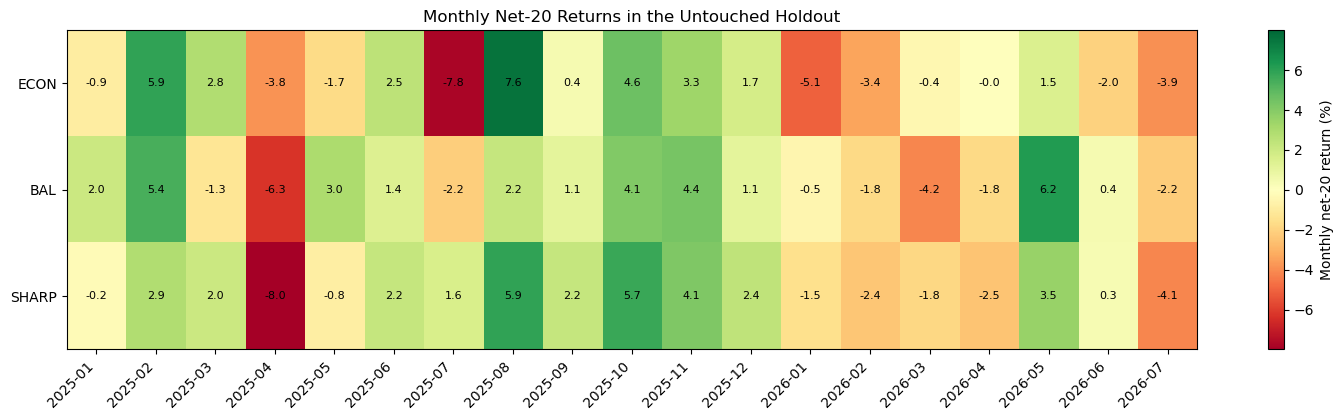

In [8]:
heat = (
    monthly.pivot(
        index="finalist",
        columns="month",
        values="net20_return",
    )
    .reindex(FINALISTS)
)
heat.columns = [
    pd.Timestamp(x).strftime("%Y-%m")
    for x in heat.columns
]
values = 100.0 * heat.to_numpy()

fig, ax = plt.subplots(figsize=(15, 4.3))
lim = np.nanmax(np.abs(values))
im = ax.imshow(
    values,
    aspect="auto",
    cmap="RdYlGn",
    vmin=-lim,
    vmax=lim,
)

ax.set_yticks(range(len(FINALISTS)))
ax.set_yticklabels(FINALISTS)
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(
    heat.columns,
    rotation=45,
    ha="right",
)

for r in range(values.shape[0]):
    for c in range(values.shape[1]):
        ax.text(
            c, r, f"{values[r, c]:.1f}",
            ha="center", va="center", fontsize=8,
        )

ax.set_title("Monthly Net-20 Returns in the Untouched Holdout")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Monthly net-20 return (%)")
fig.tight_layout()
plt.show()

## 5. Realized crypto-market exposure

Dollar-neutral weights do **not** imply zero realized market beta.

The canonical post-validation diagnostics created a common non-overlapping 48h panel containing:

- BTC return;
- point-in-time equal-weight top-25 crypto-market return;
- each finalist's net-20 strategy return.

This notebook independently recomputes the same HAC single-factor regressions from that frozen panel.

In [9]:
exposure_path = STEP13_DIR / "13D_common48_exposure_panel.parquet"
frozen_reg_path = STEP13_DIR / "13D_market_exposure_regressions.csv"

if not exposure_path.exists():
    raise FileNotFoundError(exposure_path)
if not frozen_reg_path.exists():
    raise FileNotFoundError(frozen_reg_path)

exposure = pd.read_parquet(exposure_path).copy()
exposure.index = pd.to_datetime(exposure.index, utc=True)

assert len(exposure) == 288
assert exposure.notna().all().all()


def single_factor_regression(strategy_return, factor_return):
    aligned = pd.concat(
        [
            pd.Series(strategy_return).rename("strategy"),
            pd.Series(factor_return).rename("factor"),
        ],
        axis=1,
    ).dropna()

    model = sm.OLS(
        aligned["strategy"],
        sm.add_constant(aligned["factor"]),
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 4},
    )

    return {
        "n_blocks": len(aligned),
        "correlation": float(
            aligned["strategy"].corr(aligned["factor"])
        ),
        "alpha_per_48h": float(model.params["const"]),
        "alpha_hac_t": float(model.tvalues["const"]),
        "beta": float(model.params["factor"]),
        "beta_hac_t": float(model.tvalues["factor"]),
        "r_squared": float(model.rsquared),
    }


factor_map = {
    "BTC": "btc_48h_return",
    "Crypto_market_EW": "crypto_market_48h_return",
}

reg_rows = []
for finalist in FINALISTS:
    for factor_name, factor_col in factor_map.items():
        reg_rows.append(
            {
                "finalist": finalist,
                "factor": factor_name,
                **single_factor_regression(
                    exposure[finalist],
                    exposure[factor_col],
                ),
            }
        )

regressions = pd.DataFrame(reg_rows)
frozen_reg = pd.read_csv(frozen_reg_path)

reg_merge = regressions.merge(
    frozen_reg,
    on=["finalist", "factor"],
    suffixes=("_new", "_frozen"),
    validate="one_to_one",
)

for col in [
    "correlation",
    "alpha_per_48h",
    "alpha_hac_t",
    "beta",
    "beta_hac_t",
    "r_squared",
]:
    assert (
        reg_merge[f"{col}_new"]
        - reg_merge[f"{col}_frozen"]
    ).abs().max() < 1e-10

display(
    regressions[
        [
            "finalist", "factor",
            "beta", "beta_hac_t", "r_squared",
        ]
    ].round(6)
)

print("Market-exposure regression reproduction: PASS")

,finalist,factor,beta,beta_hac_t,r_squared
0,ECON,BTC,-0.174854,-3.822067,0.115257
1,ECON,Crypto_market_EW,-0.155695,-7.297172,0.284051
2,BAL,BTC,-0.216241,-6.640757,0.211209
3,BAL,Crypto_market_EW,-0.179838,-10.290810,0.454076
4,SHARP,BTC,-0.210042,-5.524257,0.187752
5,SHARP,Crypto_market_EW,-0.178512,-9.676625,0.421537


Market-exposure regression reproduction: PASS


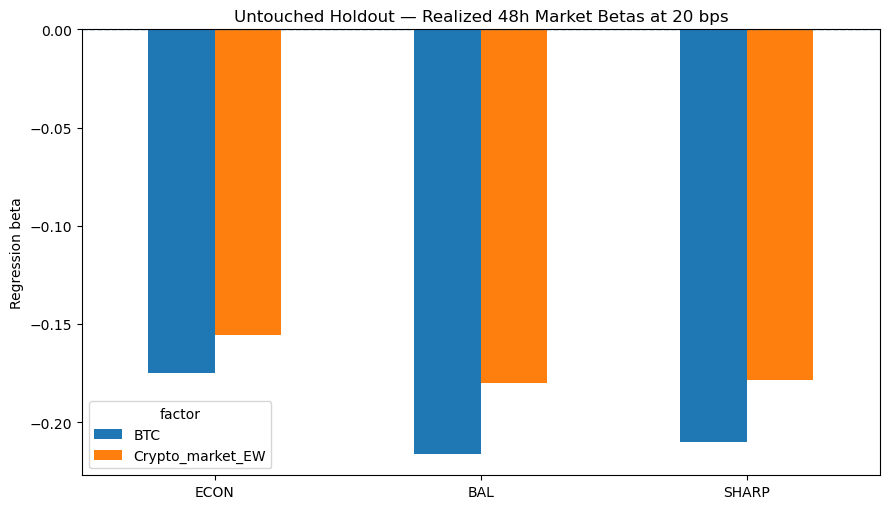

In [10]:
beta_plot = (
    regressions.pivot(
        index="finalist",
        columns="factor",
        values="beta",
    )
    .reindex(FINALISTS)
)

ax = beta_plot.plot(kind="bar", figsize=(9, 5.2))
ax.axhline(0.0, linestyle="--", linewidth=1.0)
ax.set_title("Untouched Holdout — Realized 48h Market Betas at 20 bps")
ax.set_xlabel("")
ax.set_ylabel("Regression beta")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### Market-exposure interpretation

All three finalists exhibit meaningful **negative realized beta** to both BTC and the broader point-in-time crypto-market factor.

This does not mean the portfolios are mechanically short BTC. It means that, in this holdout, the long-short continuation spread co-moved inversely with the broader market to a meaningful degree.

No beta hedge or market-state timing rule is added after the fact.

## 6. Implementation breadth and concentration

The canonical post-validation engine reconstructed the exact frozen holdings from the native 1h holdout cache and matched the Step-12 gross return paths before producing these implementation artifacts.

For the public report:

- position-count and long/short exposure summaries are loaded from those exact holdings;
- the asset-concentration statistics are independently recomputed from the saved per-asset contribution detail.

The purpose is to test whether the holdout result was dominated by a few coins or unusually narrow portfolios.

In [11]:
impl_path = STEP13_DIR / "13E_implementation_breadth_summary.csv"
detail_path = STEP13_DIR / "13E_asset_contribution_detail.parquet"
concentration_path = STEP13_DIR / "13E_asset_concentration_summary.csv"

for path in [impl_path, detail_path, concentration_path]:
    if not path.exists():
        raise FileNotFoundError(path)

implementation = pd.read_csv(impl_path)
detail = pd.read_parquet(detail_path)
frozen_concentration = pd.read_csv(concentration_path)

assert set(implementation["finalist"]) == set(FINALISTS)
assert set(detail["finalist"]) == set(FINALISTS)

# Independently reconstruct concentration from exact saved asset-contribution shares.
concentration_rows = []

for finalist in FINALISTS:
    x = (
        detail.loc[detail["finalist"].eq(finalist)]
        .sort_values("absolute_contribution_share", ascending=False)
        .reset_index(drop=True)
    )

    s = x["absolute_contribution_share"].to_numpy(float)
    assert np.isclose(s.sum(), 1.0, atol=1e-10)

    hhi = float(np.sum(s ** 2))

    concentration_rows.append(
        {
            "finalist": finalist,
            "largest_single_name_share_pct": 100.0 * s[0],
            "top3_absolute_share_pct": 100.0 * s[:3].sum(),
            "top5_absolute_share_pct": 100.0 * s[:5].sum(),
            "top10_absolute_share_pct": 100.0 * s[:10].sum(),
            "absolute_contribution_hhi": hhi,
            "effective_asset_count_from_hhi": 1.0 / hhi,
            "n_assets_with_nonzero_contribution": int((s > 0).sum()),
        }
    )

recomputed_concentration = pd.DataFrame(concentration_rows)

conc_merge = recomputed_concentration.merge(
    frozen_concentration,
    on="finalist",
    suffixes=("_new", "_frozen"),
    validate="one_to_one",
)

for col in [
    "largest_single_name_share_pct",
    "top3_absolute_share_pct",
    "top5_absolute_share_pct",
    "top10_absolute_share_pct",
    "absolute_contribution_hhi",
    "effective_asset_count_from_hhi",
]:
    assert (
        conc_merge[f"{col}_new"]
        - conc_merge[f"{col}_frozen"]
    ).abs().max() < 1e-10

headline_cols = [
    "finalist",
    "median_active_names",
    "median_effective_n",
    "mean_long_exposure",
    "mean_short_exposure",
    "mean_net_exposure",
    "largest_single_name_share_pct",
    "top5_absolute_share_pct",
    "effective_asset_count_from_hhi",
]

headline_impl = implementation[headline_cols].copy()
display(headline_impl.round(6))

# Frozen headline checks from the final research record.
expected_active = {"ECON": 30.0, "BAL": 29.0, "SHARP": 31.0}
for finalist, expected in expected_active.items():
    actual = float(
        implementation.loc[
            implementation["finalist"].eq(finalist),
            "median_active_names",
        ].iloc[0]
    )
    assert np.isclose(actual, expected, atol=1e-12)

assert implementation["largest_single_name_share_pct"].max() < 6.7
assert implementation["top5_absolute_share_pct"].max() < 23.5
assert np.allclose(
    implementation["mean_long_exposure"],
    0.5,
    atol=1e-10,
)
assert np.allclose(
    implementation["mean_short_exposure"],
    0.5,
    atol=1e-10,
)

print("Asset-concentration reproduction: PASS")
print("Frozen implementation-breadth checks: PASS")

,finalist,median_active_names,median_effective_n,mean_long_exposure,mean_short_exposure,mean_net_exposure,largest_single_name_share_pct,top5_absolute_share_pct,effective_asset_count_from_hhi
0,ECON,30.0,18.806002,0.5,0.5,-0.0,5.917652,22.771846,37.353243
1,BAL,29.0,19.873993,0.5,0.5,0.0,6.599658,22.728710,36.495675
2,SHARP,31.0,19.533030,0.5,0.5,0.0,6.186178,23.300958,36.697046


Asset-concentration reproduction: PASS
Frozen implementation-breadth checks: PASS


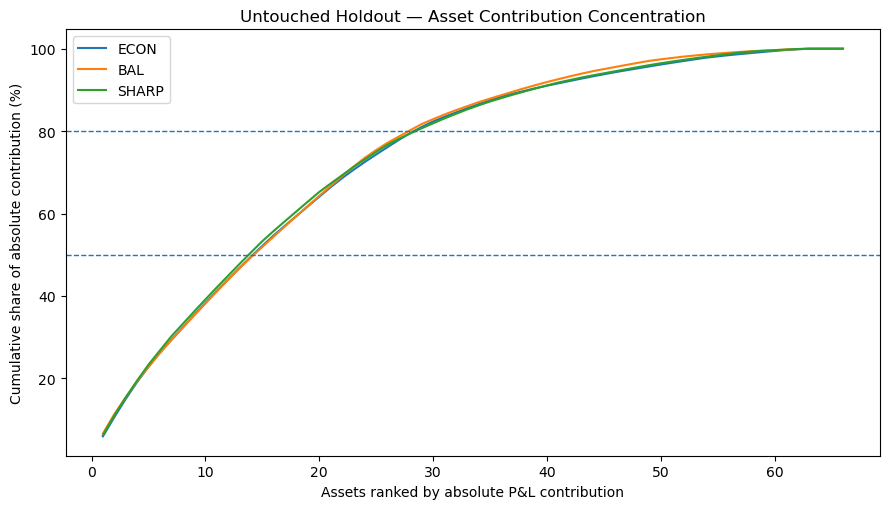

In [12]:
fig, ax = plt.subplots(figsize=(9, 5.2))

for finalist in FINALISTS:
    x = (
        detail.loc[detail["finalist"].eq(finalist)]
        .sort_values("rank")
    )
    ax.plot(
        x["rank"],
        100.0 * x["cumulative_absolute_share"],
        label=finalist,
    )

ax.axhline(50.0, linestyle="--", linewidth=1.0)
ax.axhline(80.0, linestyle="--", linewidth=1.0)
ax.set_xlabel("Assets ranked by absolute P&L contribution")
ax.set_ylabel("Cumulative share of absolute contribution (%)")
ax.set_title("Untouched Holdout — Asset Contribution Concentration")
ax.legend()
fig.tight_layout()
plt.show()

### Long/short attribution

In the realized final holdout, the continuation spread monetized primarily through stronger underperformance of the short-side losers, while the long leg had negative absolute P&L.

That is **not** used to redesign the portfolio. A cross-sectional long-short continuation strategy targets the winner-minus-loser spread; absolute long- and short-leg P&L can depend on market state.

Neither leg is removed.

In [13]:
leg_cols = [
    "finalist",
    "total_gross_pnl_arithmetic",
    "long_leg_contribution",
    "short_leg_contribution",
    "mean_long_exposure",
    "mean_short_exposure",
    "mean_net_exposure",
]

display(implementation[leg_cols].round(6))

,finalist,total_gross_pnl_arithmetic,long_leg_contribution,short_leg_contribution,mean_long_exposure,mean_short_exposure,mean_net_exposure
0,ECON,0.118606,-0.323014,0.441619,0.5,0.5,-0.0
1,BAL,0.253833,-0.271277,0.525110,0.5,0.5,0.0
2,SHARP,0.364479,-0.230982,0.595461,0.5,0.5,0.0


## 7. Final technical conclusion

The post-validation diagnostics strengthen the implementation story without changing the research result:

- all three finalists retain positive execution-cost headroom above the locked 20-bps assumption;
- BAL has the mildest realized downside profile and the strongest cost cushion;
- SHARP retains the strongest gross holdout performance but at materially higher turnover;
- performance is temporally uneven, with a much stronger 2025 than Jan–Jul 2026;
- the portfolios are dollar-neutral in weights but carry meaningful negative realized crypto-market beta;
- typical portfolios remain broad, with roughly 29–31 active names and low single-name contribution concentration.

The limitations remain part of the conclusion:

- performance degraded materially versus pre-2025 evidence;
- drawdowns were long and economically meaningful;
- the final sample is short;
- market beta is nonzero;
- the three finalists are highly correlated implementations of one continuation factor.

**No retuning, filtering, asset exclusion, leg redesign, beta hedge, combination fitting, or post-holdout winner selection is performed.**

Empirical research is now frozen. Repository engineering and presentation work may reorganize the code and narrative, but they may not change these conclusions.